In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import rateslib as rl
import QuantLib as ql

import datetime
import pytz

NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC") 

In [2]:
from Query.IRSwaps.IRSwapQuery import IRSwapQuery, IRSwapStructure
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB, IRSwapValueFunctionMap 
from Query.IRSwaps.IRSwapStructure import IRSwapStructureFunctionMap
from Query.IRSwaps.IRSwapValue import IRSwapValue

from utils.ql_utils import datetime_to_ql_date, ql_date_to_datetime 

In [3]:
# import logging, sys
# for h in logging.root.handlers[:]:
#     logging.root.removeHandler(h)
# logging.basicConfig(
#     level=logging.ERROR,  # or DEBUG
#     stream=sys.stdout,  # send logs to the cell output
#     format="%(asctime)s %(levelname)s [%(name)s] %(message)s",
# )
# logging.getLogger("IRSwapsTB").setLevel(logging.ERROR)
# logging.captureWarnings(True)

import logging
logging.disable(logging.CRITICAL)

In [4]:
# 2025-09-20 18:09:30,966 CRITICAL [ZODB.DB] DB.open() has 19 open connections with a pool_size of 7

In [4]:
# curve_mdp = IRSwapsMDP(source="CME_NY_EOD_LIVE-ql_basic")
# curve_mdp = IRSwapsMDP(source="GSQUANT-rl_basic")
# curve_mdp = IRSwapsMDP(source="SDR_INTRADAY-rl_usd_sofr_mt_q12")
# curve_mdp = IRSwapsMDP(source="SDR_INTRADAY-rl_usd_sofr_mt_misc")
curve_mdp = IRSwapsMDP(source="SDR_INTRADAY-rl_usd_sofr_mtv2_q12x11")
# curve_mdp = IRSwapsMDP(source="SDR_INTRADAY-rl_usd_ois_stir_q12x12", force_refresh_fixings=False)
# irs_tb = IRSwapsTB(mdp=curve_mdp, force_refresh=True)

In [20]:
# ts = datetime.date(2025, 9, 24)
ts = NY_tz.localize(datetime.datetime(2025, 9, 24, 7, 00))
# ts = "live"

curve_handle = curve_mdp._get_curve(curve_name="USD-SOFR-1D", timestamp=ts)
curve_handle.handle()

<rl.Curve:2025-09-24 07:00:00-04:00-SDR_INTRADAY-RL_USD_SOFR_MTV2_Q12x11 at 0x1b317ed42b0>

In [5]:
def ql_cal_date_range(ql_cal: ql.Calendar, start: datetime.datetime, end: datetime.datetime):
    assert start.tzinfo is not None, "must be tz aware!"
    assert start.tzinfo == end.tzinfo, "must be from same tz!"
    assert start.time() == end.time(), "must be same closes!"
    
    def _to_ql_date(dt: datetime.datetime):
        return ql.Date(dt.day, dt.month, dt.year)
    
    pd_range = pd.date_range(start=start, end=end, freq="1b")
    return [d for d in pd_range if ql_cal.isBusinessDay(_to_ql_date(d))]

In [6]:
tb = IRSwapsTB(mdp=curve_mdp)

In [8]:
# start = datetime.date(2025, 1, 1)
# end = datetime.date(2025, 9, 26)

# start = NY_tz.localize(datetime.datetime(2025, 9, 17, 7, 00))
# end = NY_tz.localize(datetime.datetime(2025, 9, 17, 17, 00))
# nycloses = ql_cal_date_range(
#     ql_cal=ql.UnitedStates(ql.UnitedStates.GovernmentBond),
# start=NY_tz.localize(datetime.datetime(2025, 9, 15, 17, 00)),
# end=NY_tz.localize(datetime.datetime(2025, 9, 19, 17, 00)),
# )

intraday = pd.date_range(start=NY_tz.localize(datetime.datetime(2025, 9, 17, 7, 00)), end=NY_tz.localize(datetime.datetime(2025, 9, 17, 17, 00)), freq="1min")

q = IRSwapQuery(curve="USD-SOFR-1D", tenor="10Y")

In [10]:
df = tb.get_timeseries(start=None, end=None, timestamps=intraday, queries=[q], n_jobs=12)
df

,USD-SOFR-1D 10Y OUTRIGHT RATE
Date,
2025-09-17 07:00:00-04:00,3.489450
2025-09-17 07:01:00-04:00,3.489450
2025-09-17 07:02:00-04:00,3.489450
2025-09-17 07:03:00-04:00,3.489450
2025-09-17 07:04:00-04:00,3.489450
...,...
2025-09-17 16:56:00-04:00,3.566555
2025-09-17 16:57:00-04:00,3.569500
2025-09-17 16:58:00-04:00,3.569500


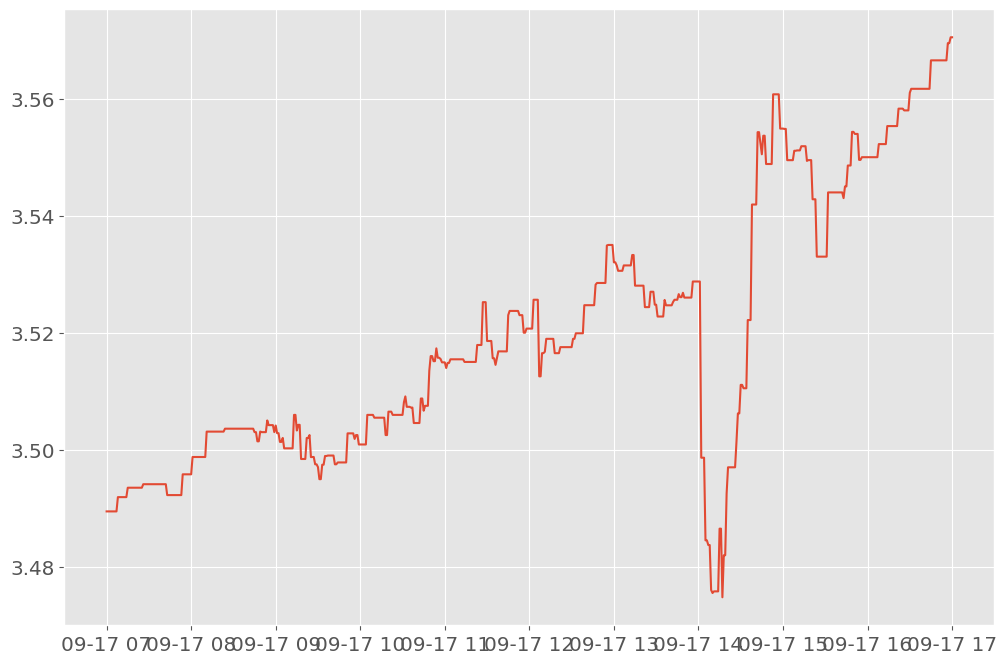

In [11]:
plt.plot(df.index, df[q.col_name()])

In [38]:
curve_mdp.bulk_get_data(request={"curve_name": "USD-SOFR-1D", "timestamps": ["live"], "ignore_cache": True})

FETCHING ERIS INTRADAY DISC CURVE...: 100%|██████████| 1/1 [00:00<00:00,  2.49it/s]


{datetime.date(2025, 9, 26): QLIRSwapCurve(_ql_curve_id='USD-SOFR-1D', _ql_curve_handle=<QuantLib.QuantLib.YieldTermStructureHandle; proxy of <Swig Object of type 'Handle< YieldTermStructure > *' at 0x00000206F225D1A0> >, _ql_curve_index=<QuantLib.QuantLib.Sofr; proxy of <Swig Object of type 'ext::shared_ptr< Sofr > *' at 0x00000206EEF53000> >, _meta_data={'timestamp': datetime.datetime(2025, 9, 26, 14, 2, 53, tzinfo=<DstTzInfo 'America/New_York' EDT-1 day, 20:00:00 DST>)})}